In [1]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.inspection import permutation_importance
import matplotlib.patches as mpatches
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import precision_recall_curve, average_precision_score
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Wczytywanie

In [2]:
df = pd.read_csv(r"C:\Users\wesol\OneDrive\Pulpit\Studia\Semestr VII\Inżynierka\healthcare-dataset-stroke-data.csv")
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
df.info() #sa braki w danych

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [4]:
#do pracy:
basic_info_before = pd.DataFrame({
    "Metryka": [
        "Liczba obserwacji",
        "Liczba kolumn",
        "Liczba braków (NA)",
        "Liczba zmiennych numerycznych",
        "Liczba zmiennych kategorycznych"
    ],
    "Wartość": [
        df.shape[0],
        df.shape[1],
        int(df.isna().sum().sum()),
        df.select_dtypes(include=["int64", "float64"]).shape[1],
        df.select_dtypes(include=["object"]).shape[1]
    ]
})

basic_info_before

,Metryka,Wartość
0,Liczba obserwacji,5110
1,Liczba kolumn,12
2,Liczba braków (NA),201
3,Liczba zmiennych numerycznych,7
4,Liczba zmiennych kategorycznych,5


In [5]:
df.isnull().sum() #braki w BMI

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

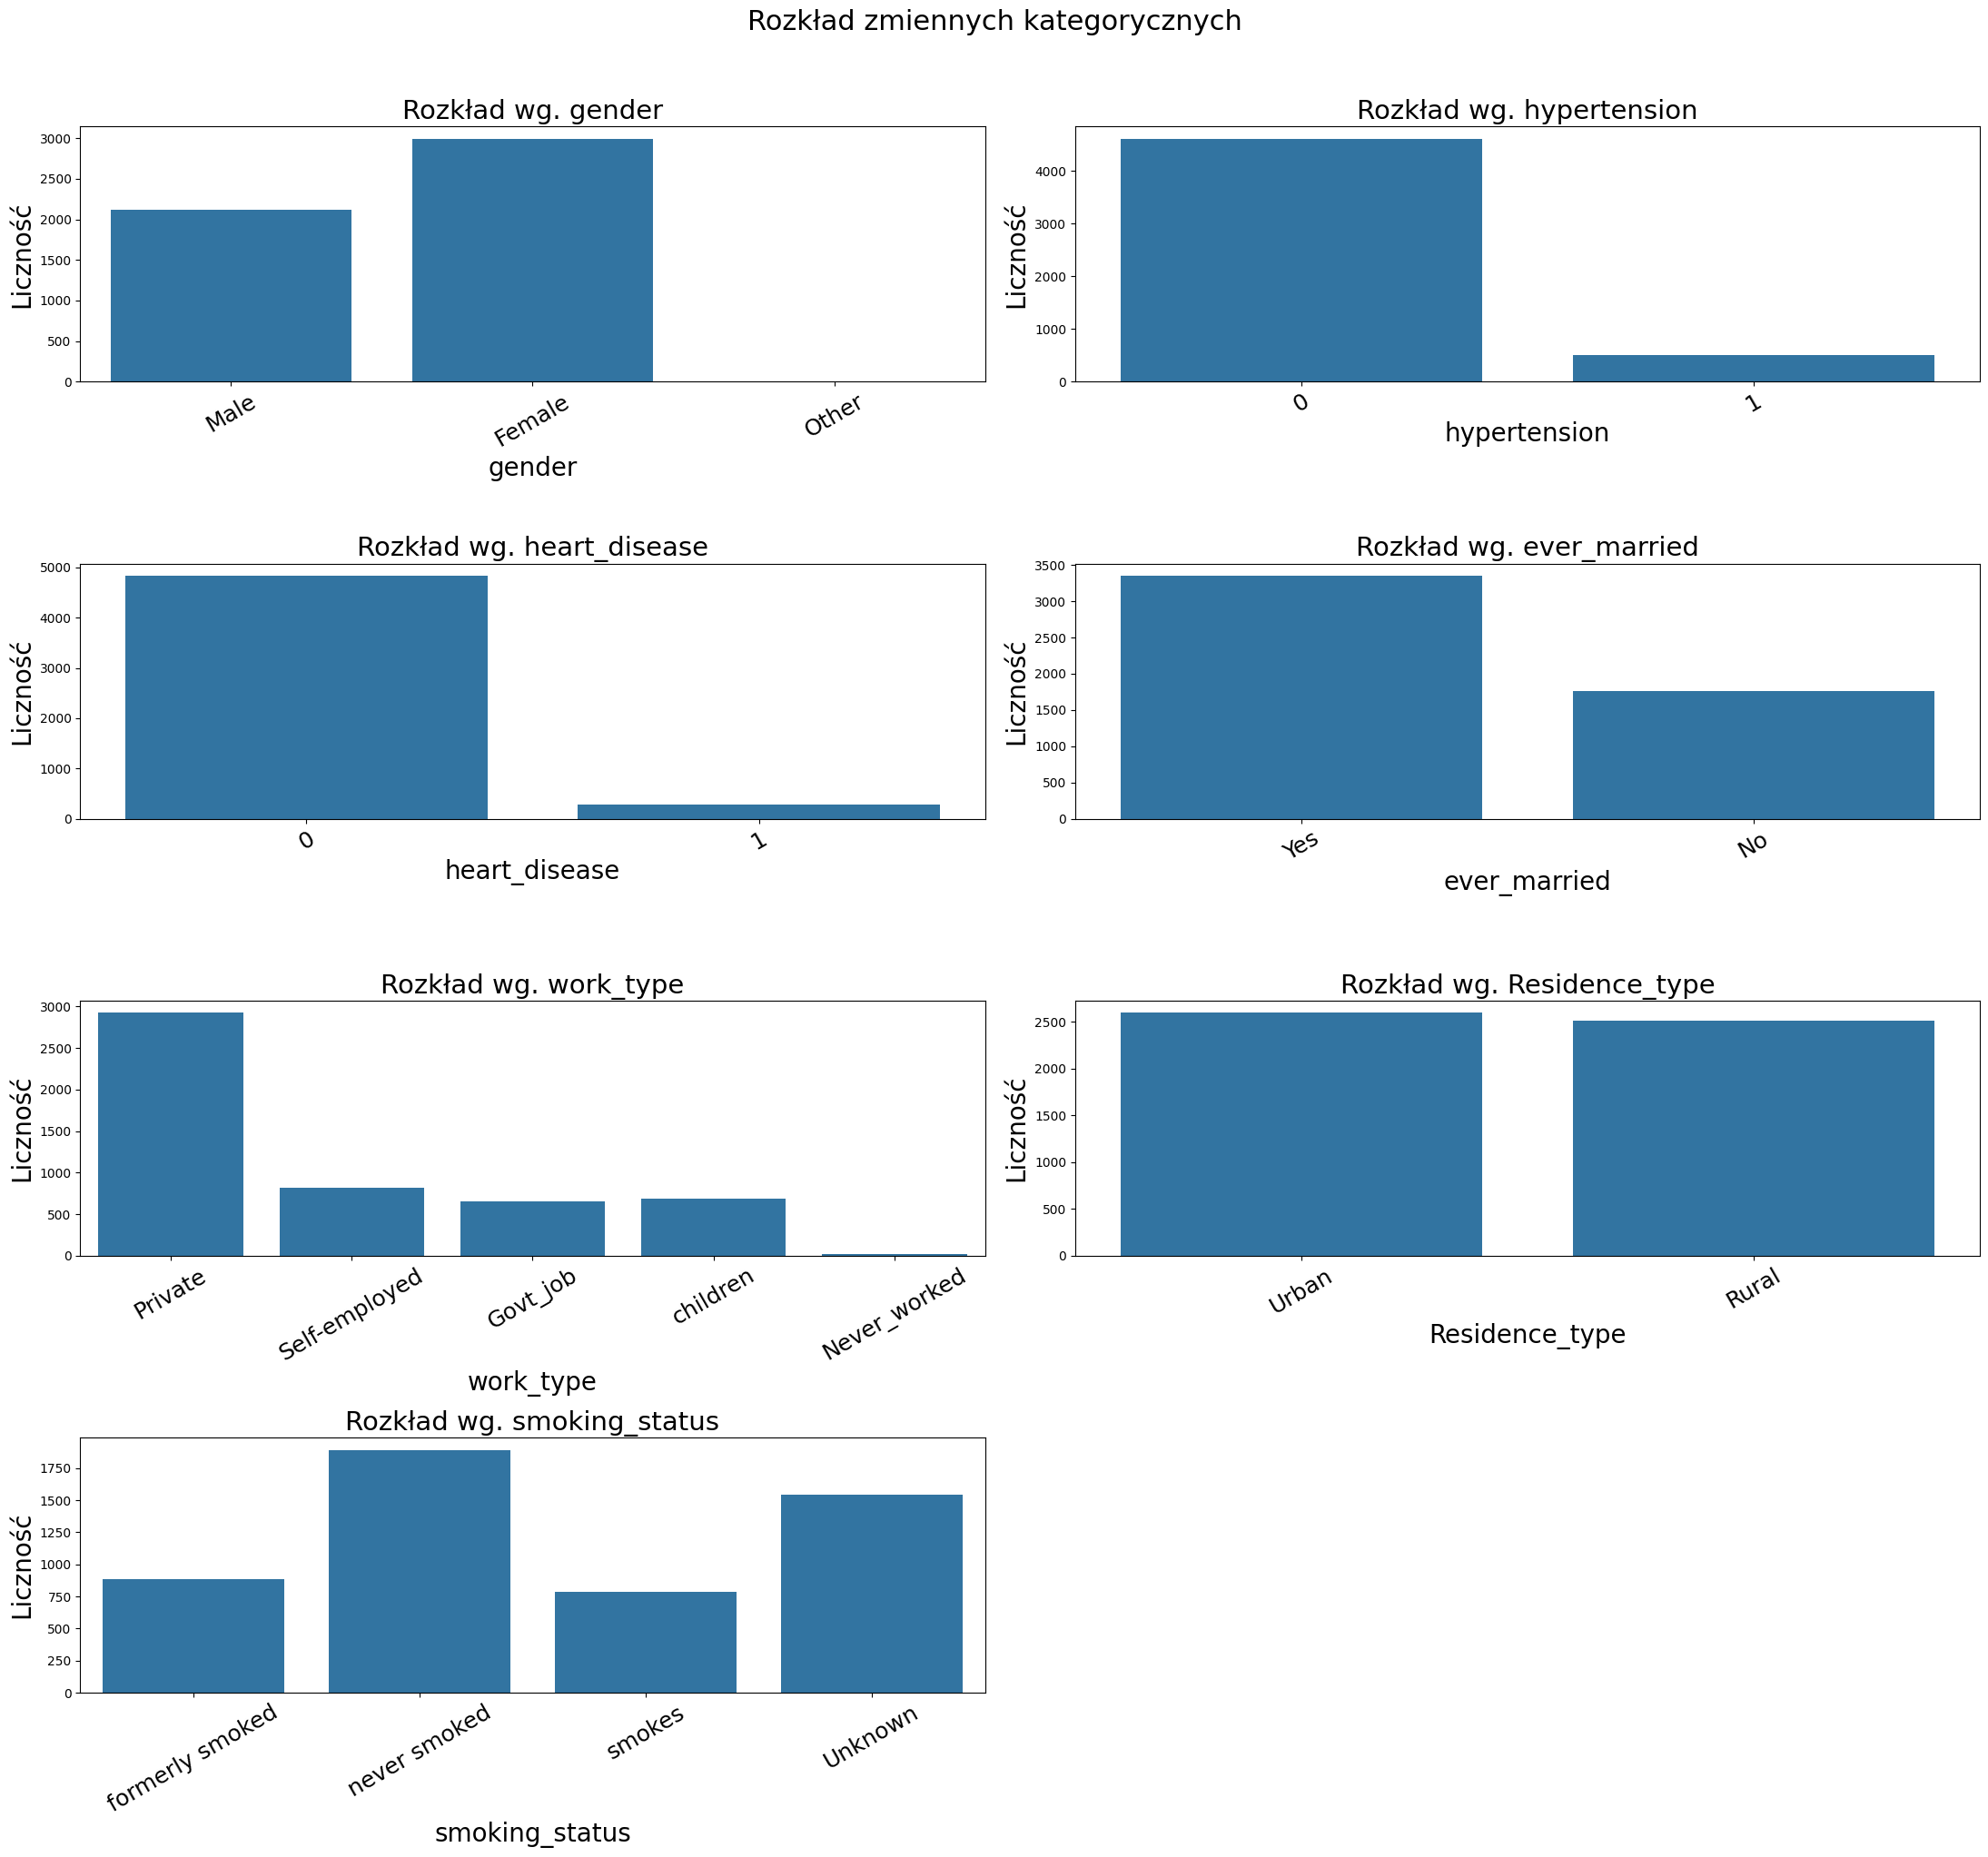

In [6]:
columns = ['gender', 'hypertension', 'heart_disease',
                    'ever_married', 'work_type', 'Residence_type', 'smoking_status']

cat_cols = ['gender', 'ever_married', 'work_type',
            'Residence_type', 'smoking_status']

fig, axes = plt.subplots(4, 2, figsize=(22, 20))
axes = axes.flatten()

for ax, col in zip(axes, columns):
    sns.countplot(x=col, data=df, ax=ax)
    ax.set_title(f"Rozkład wg. {col}", fontsize=21)
    ax.set_xlabel(col, fontsize=20)
    ax.set_ylabel("Liczność", fontsize=20)
    ax.tick_params(axis='x', rotation=30, labelsize=18)

# usuń pusty subplot (bo 8 osi, a kolumn 7)
fig.delaxes(axes[-1])

fig.suptitle("Rozkład zmiennych kategorycznych", fontsize=22, y=1.02)
plt.tight_layout()
plt.savefig("Szablon_praca_inzynierska_GIN_IAD 1/img/categorical_distributions.png", dpi=300)
plt.show()

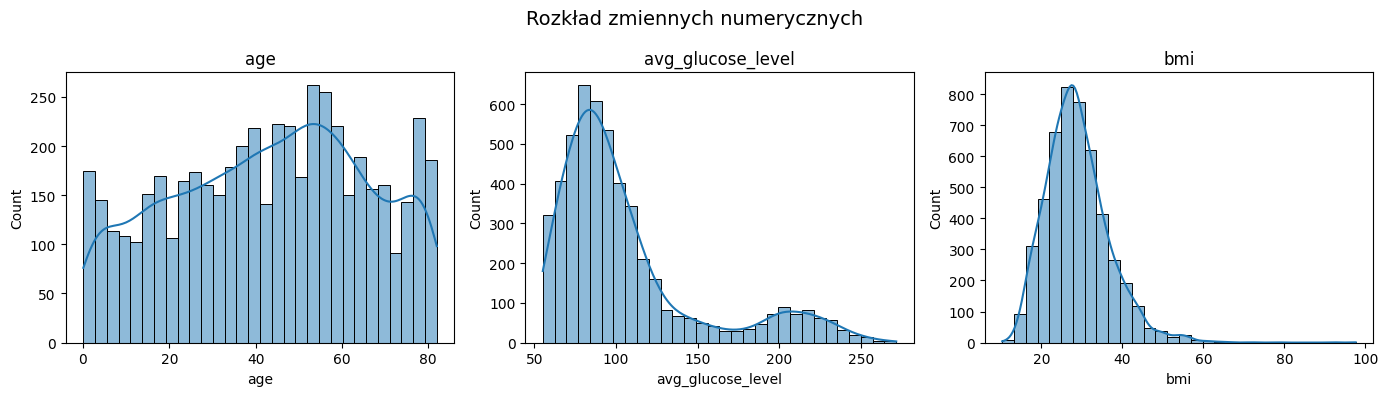

In [7]:
num_cols = ['age', 'avg_glucose_level', 'bmi']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], kde=True, bins=30, ax=ax)
    ax.set_title(col)
    ax.set_xlabel(col)

fig.suptitle("Rozkład zmiennych numerycznych", fontsize=14)
plt.tight_layout()
plt.savefig("Szablon_praca_inzynierska_GIN_IAD 1/img/numerical_distributions.png", dpi=300)
plt.show()

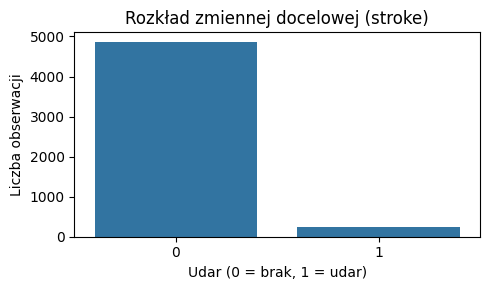

In [8]:
#rozklad udarow

plt.figure(figsize=(5,3))
sns.countplot(x="stroke", data=df)
plt.title("Rozkład zmiennej docelowej (stroke)")
plt.xlabel("Udar (0 = brak, 1 = udar)")
plt.ylabel("Liczba obserwacji")
plt.tight_layout()
plt.savefig("Szablon_praca_inzynierska_GIN_IAD 1/img/stroke_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# Czyszczenie danych

In [9]:
#id zbedne
df = df.drop(columns=['id'], errors='ignore')

#zamiana wieku na int
df['age'] = df['age'].round(0).astype(int)

#z object na category
for col in ['gender','ever_married','work_type','Residence_type','smoking_status']:
    df[col] = df[col].astype('category')

#usuniecie other zeby nie zaburzalo wynikow
df = df[df['gender'] != 'Other']
df['gender'] = df['gender'].cat.remove_unused_categories()

#usuwamy wiersze gdzie sa braki
df = df.dropna(subset=['bmi'])
df.info() 

<class 'pandas.core.frame.DataFrame'>
Index: 4908 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   gender             4908 non-null   category
 1   age                4908 non-null   int32   
 2   hypertension       4908 non-null   int64   
 3   heart_disease      4908 non-null   int64   
 4   ever_married       4908 non-null   category
 5   work_type          4908 non-null   category
 6   Residence_type     4908 non-null   category
 7   avg_glucose_level  4908 non-null   float64 
 8   bmi                4908 non-null   float64 
 9   smoking_status     4908 non-null   category
 10  stroke             4908 non-null   int64   
dtypes: category(5), float64(2), int32(1), int64(3)
memory usage: 273.9 KB


In [10]:
#do pracy
basic_info_after = pd.DataFrame({
    "Metryka": [
        "Liczba obserwacji",
        "Liczba kolumn",
        "Braki danych",
        "Zmienne numeryczne",
        "Zmienne kategoryczne"
    ],
    "Wartość": [
        df.shape[0],
        df.shape[1],
        int(df.isna().sum().sum()),
        df.select_dtypes(include=["int64", "int32", "float64"]).shape[1],
        df.select_dtypes(include=["category"]).shape[1]
    ]
})

basic_info_after

,Metryka,Wartość
0,Liczba obserwacji,4908
1,Liczba kolumn,11
2,Braki danych,0
3,Zmienne numeryczne,6
4,Zmienne kategoryczne,5


# Nie uzywane

In [11]:
'''
#dodanie grup wiekowych
def categorize_age(age):
    if age < 18:
        return 'child'
    elif age < 36:
        return 'young_adult'
    elif age < 56:
        return 'middle_aged'
    elif age < 76:
        return 'senior'
    else:
        return 'elderly'

df['age_group'] = df['age'].apply(categorize_age)
df['age_group'] = df['age_group'].astype('category')

'''

"\n#dodanie grup wiekowych\ndef categorize_age(age):\n    if age < 18:\n        return 'child'\n    elif age < 36:\n        return 'young_adult'\n    elif age < 56:\n        return 'middle_aged'\n    elif age < 76:\n        return 'senior'\n    else:\n        return 'elderly'\n\ndf['age_group'] = df['age'].apply(categorize_age)\ndf['age_group'] = df['age_group'].astype('category')\n\n"

In [12]:
#normalizacja
'''
USE_NORMALIZATION = True   #(True = normalizacja, False = brak)

num_cols = ['age', 'avg_glucose_level', 'bmi']

scaler_for_df = MinMaxScaler()
df_norm = df.copy()
df_norm[num_cols] = scaler_for_df.fit_transform(df_norm[num_cols])

if USE_NORMALIZATION:
    df = df_norm
else:
    df = df

'''

"\nUSE_NORMALIZATION = True   #(True = normalizacja, False = brak)\n\nnum_cols = ['age', 'avg_glucose_level', 'bmi']\n\nscaler_for_df = MinMaxScaler()\ndf_norm = df.copy()\ndf_norm[num_cols] = scaler_for_df.fit_transform(df_norm[num_cols])\n\nif USE_NORMALIZATION:\n    df = df_norm\nelse:\n    df = df\n\n"

# EDA

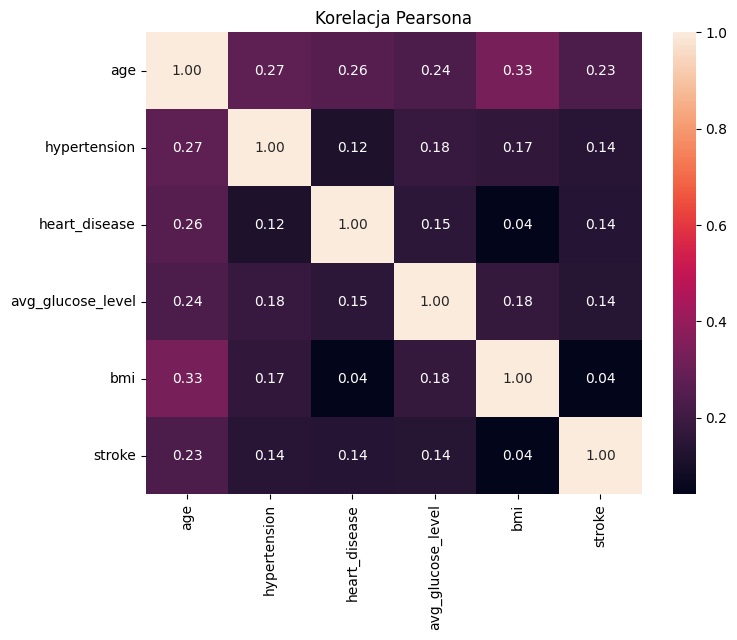

In [13]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Korelacja Pearsona")
plt.savefig("Szablon_praca_inzynierska_GIN_IAD 1/img/correlation_matrix.png", dpi=300)
plt.show()

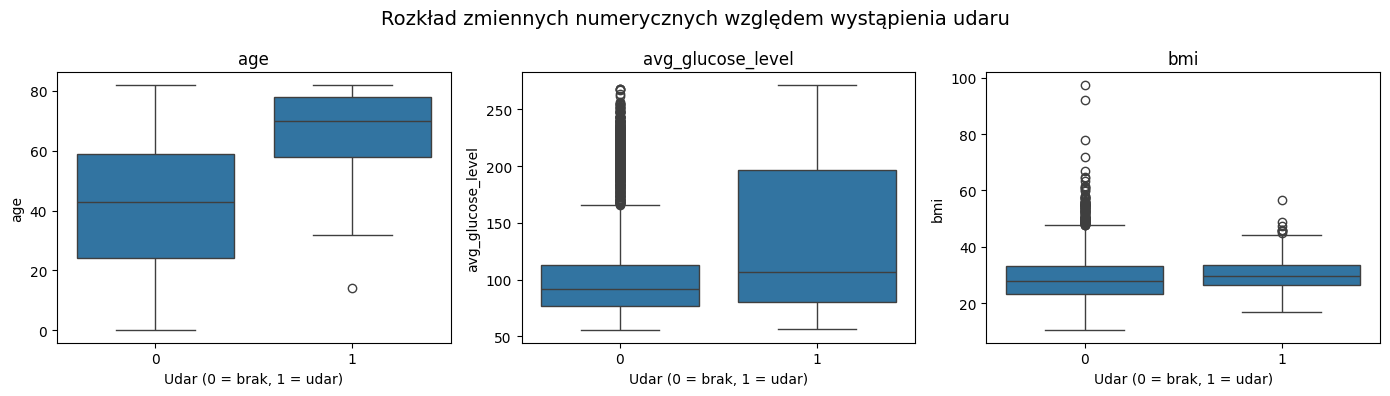

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, num_cols):
    sns.boxplot(x='stroke', y=col, data=df, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("Udar (0 = brak, 1 = udar)")
    ax.set_ylabel(col)

fig.suptitle("Rozkład zmiennych numerycznych względem wystąpienia udaru", fontsize=14)
plt.tight_layout()
plt.savefig("Szablon_praca_inzynierska_GIN_IAD 1/img/boxplot_numeric_vs_stroke.png", dpi=300)
plt.show()

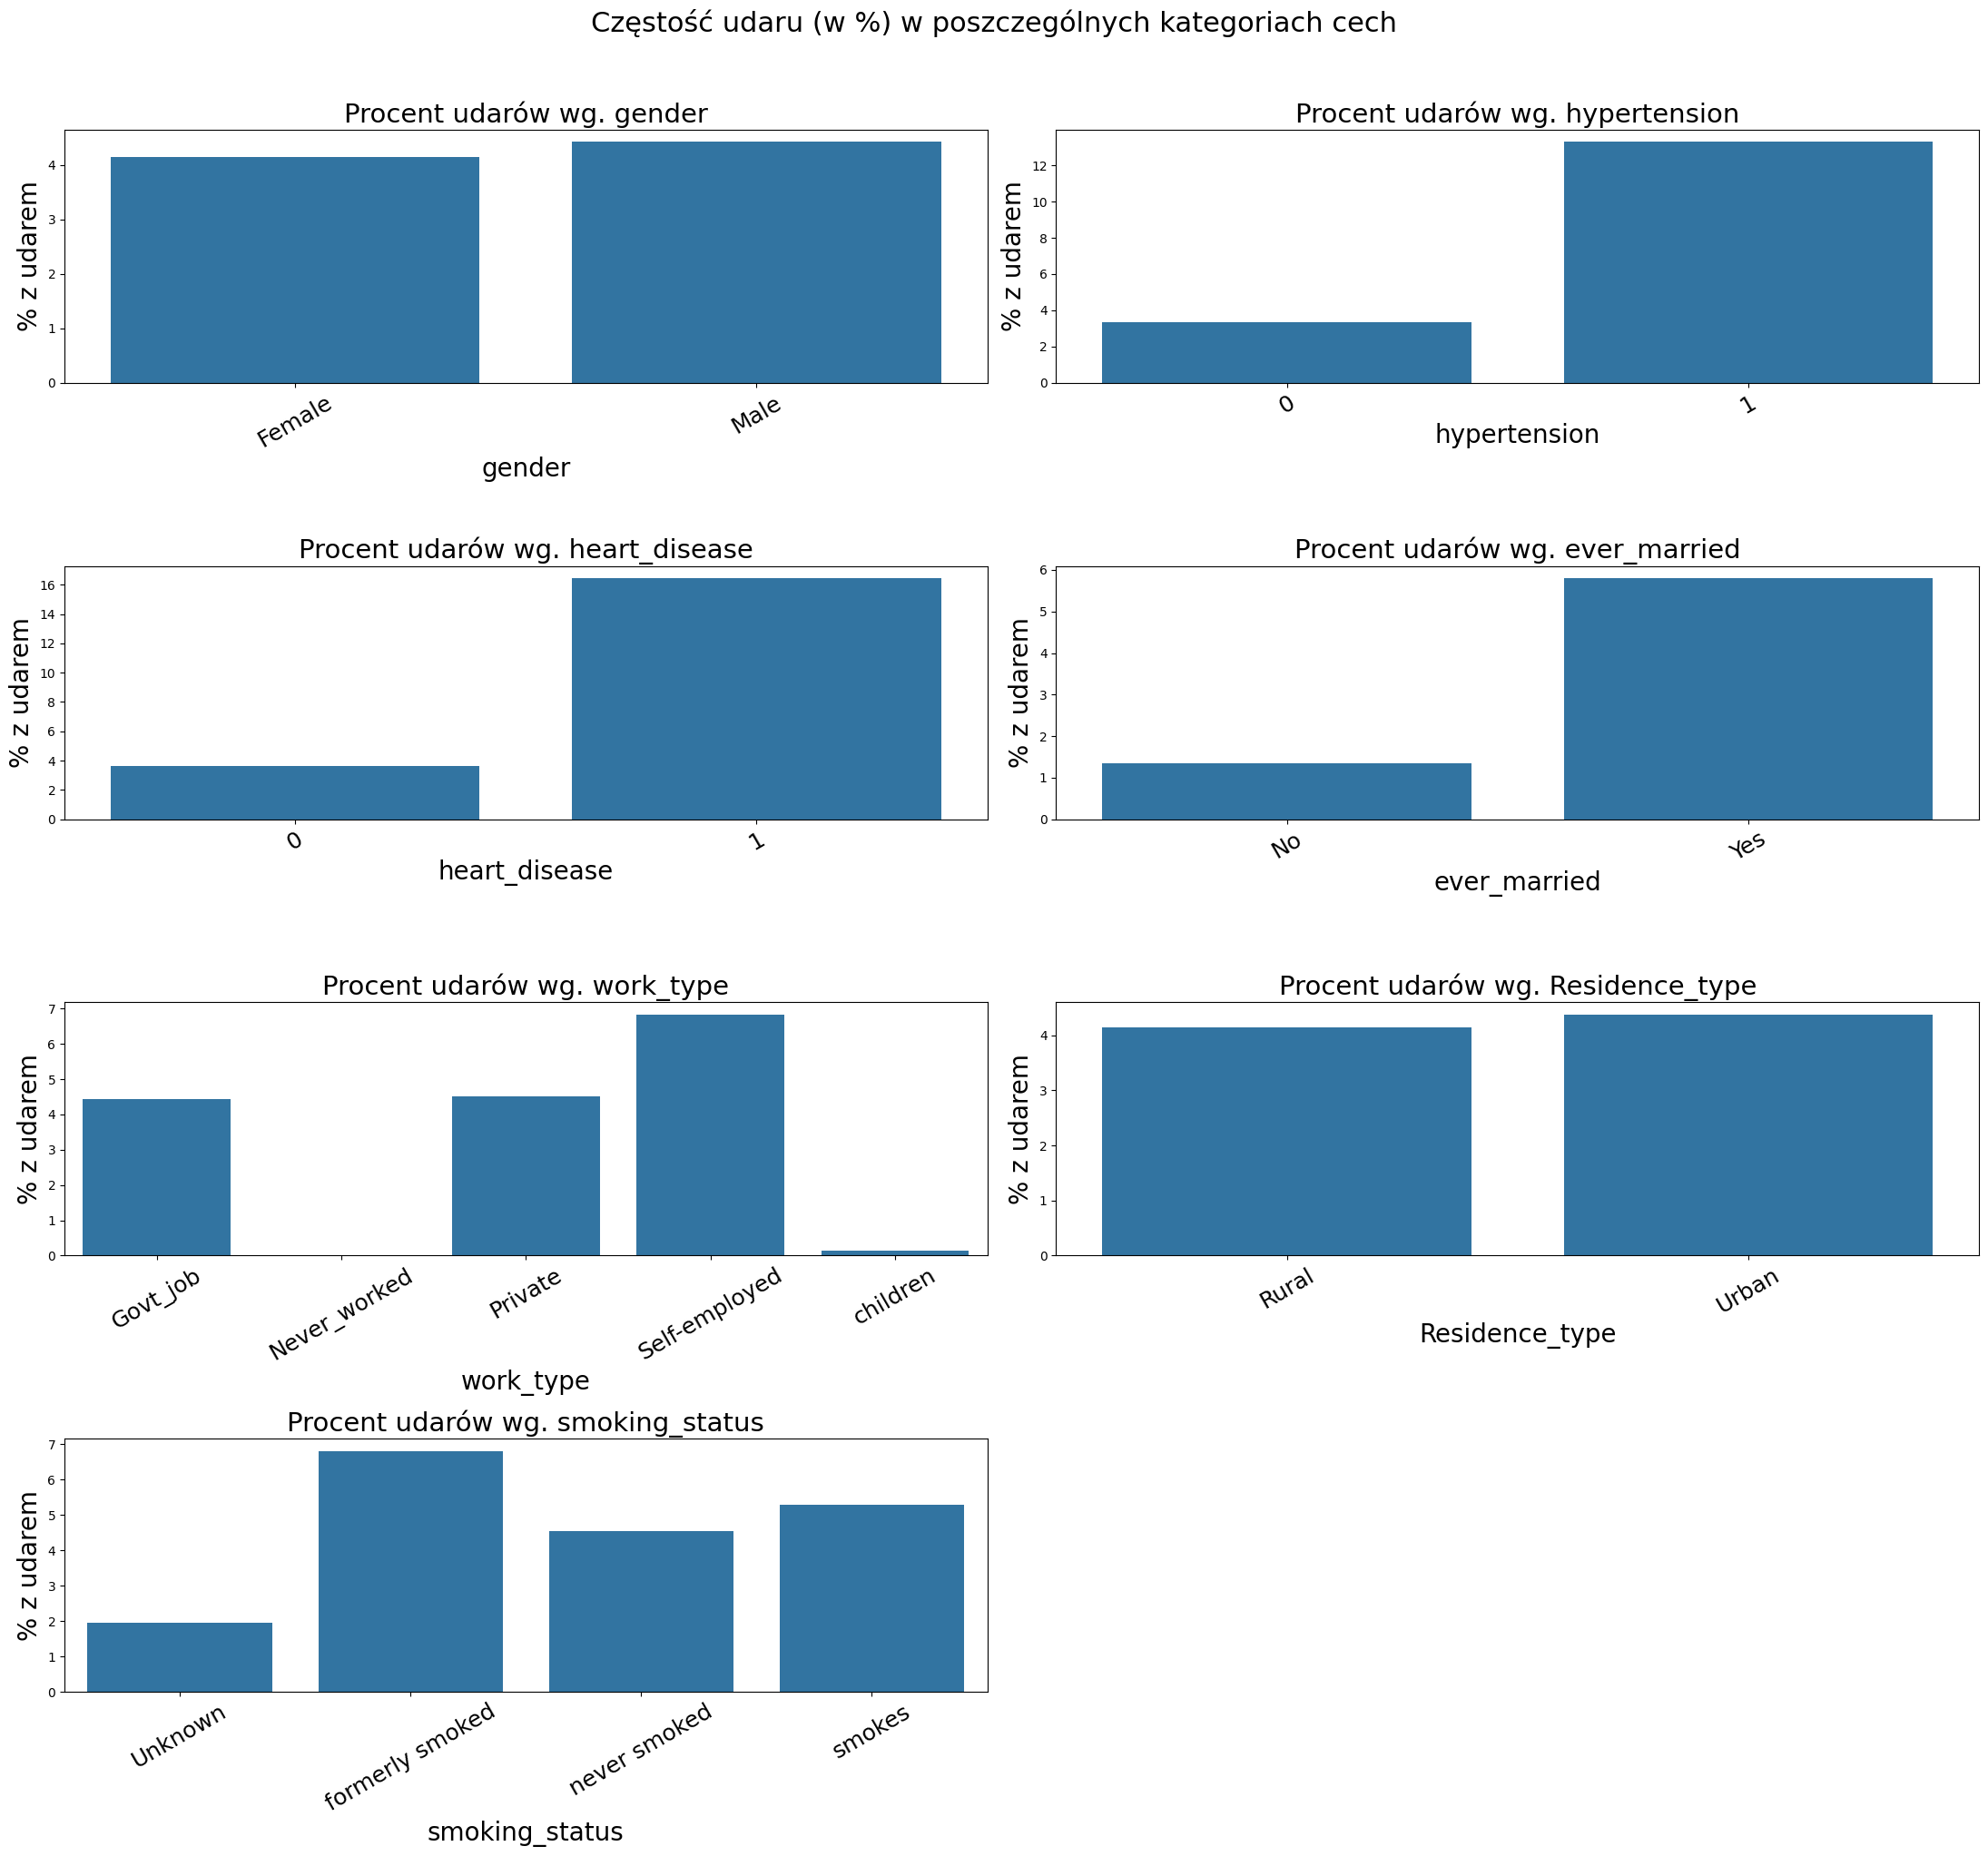

In [15]:
fig, axes = plt.subplots(4, 2, figsize=(22, 20))
axes = axes.flatten()

for ax, col in zip(axes, columns):
    sns.barplot(x=col, y='stroke', data=df, estimator=lambda x: 100*sum(x)/len(x),errorbar=None, ax=ax)
    ax.set_title(f"Procent udarów wg. {col}", fontsize=21)
    ax.set_xlabel(col, fontsize=20)
    ax.set_ylabel("% z udarem", fontsize=20)
    ax.tick_params(axis='x', rotation=30, labelsize=18)

# usuń pusty subplot
fig.delaxes(axes[-1])

fig.suptitle("Częstość udaru (w %) w poszczególnych kategoriach cech", fontsize=22, y=1.02)
plt.tight_layout()
plt.savefig("Szablon_praca_inzynierska_GIN_IAD 1/img/stroke_by_categorical.png", dpi=300)
plt.show()

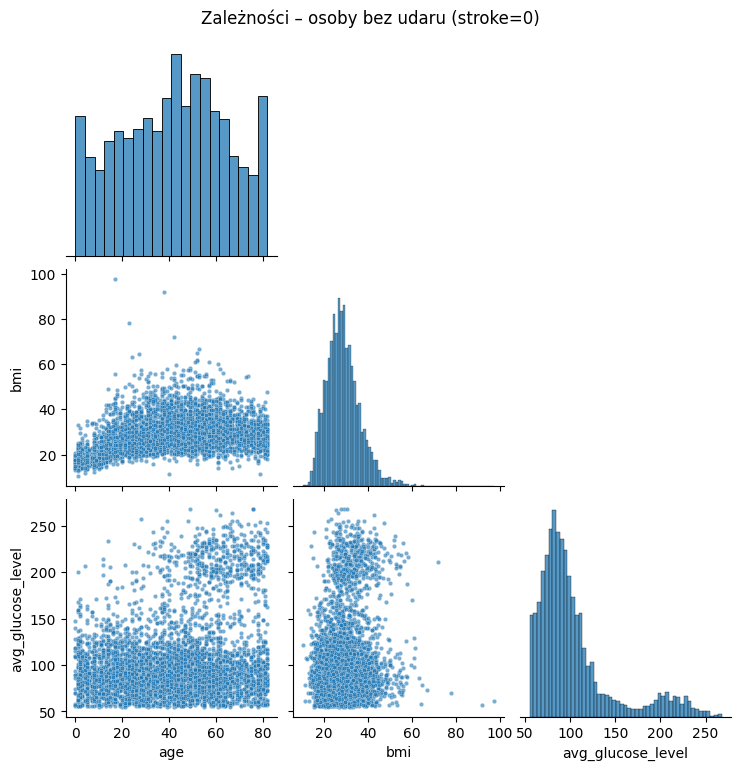

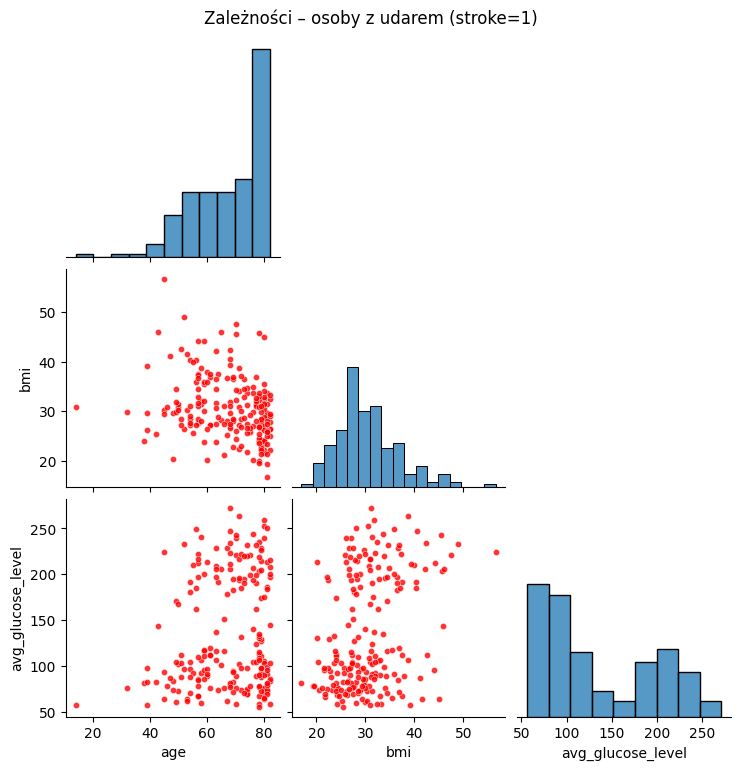

In [16]:
#Osoby bez udaru
sns.pairplot(
    df[df['stroke'] == 0],
    vars=['age', 'bmi', 'avg_glucose_level'],
    corner=True,
    plot_kws={'s': 10, 'alpha': 0.6}
)
plt.suptitle("Zależności – osoby bez udaru (stroke=0)", y=1.02)
plt.savefig("Szablon_praca_inzynierska_GIN_IAD 1/img/no_stroke_by_numerical.png", dpi=300)
plt.show()

#Osoby z udarem
sns.pairplot(
    df[df['stroke'] == 1],
    vars=['age', 'bmi', 'avg_glucose_level'],
    corner=True,
    plot_kws={'s': 20, 'alpha': 0.8, 'color': 'red'}
)
plt.suptitle("Zależności – osoby z udarem (stroke=1)", y=1.02)
plt.savefig("Szablon_praca_inzynierska_GIN_IAD 1/img/stroke_by_numerical.png", dpi=300)
plt.show()

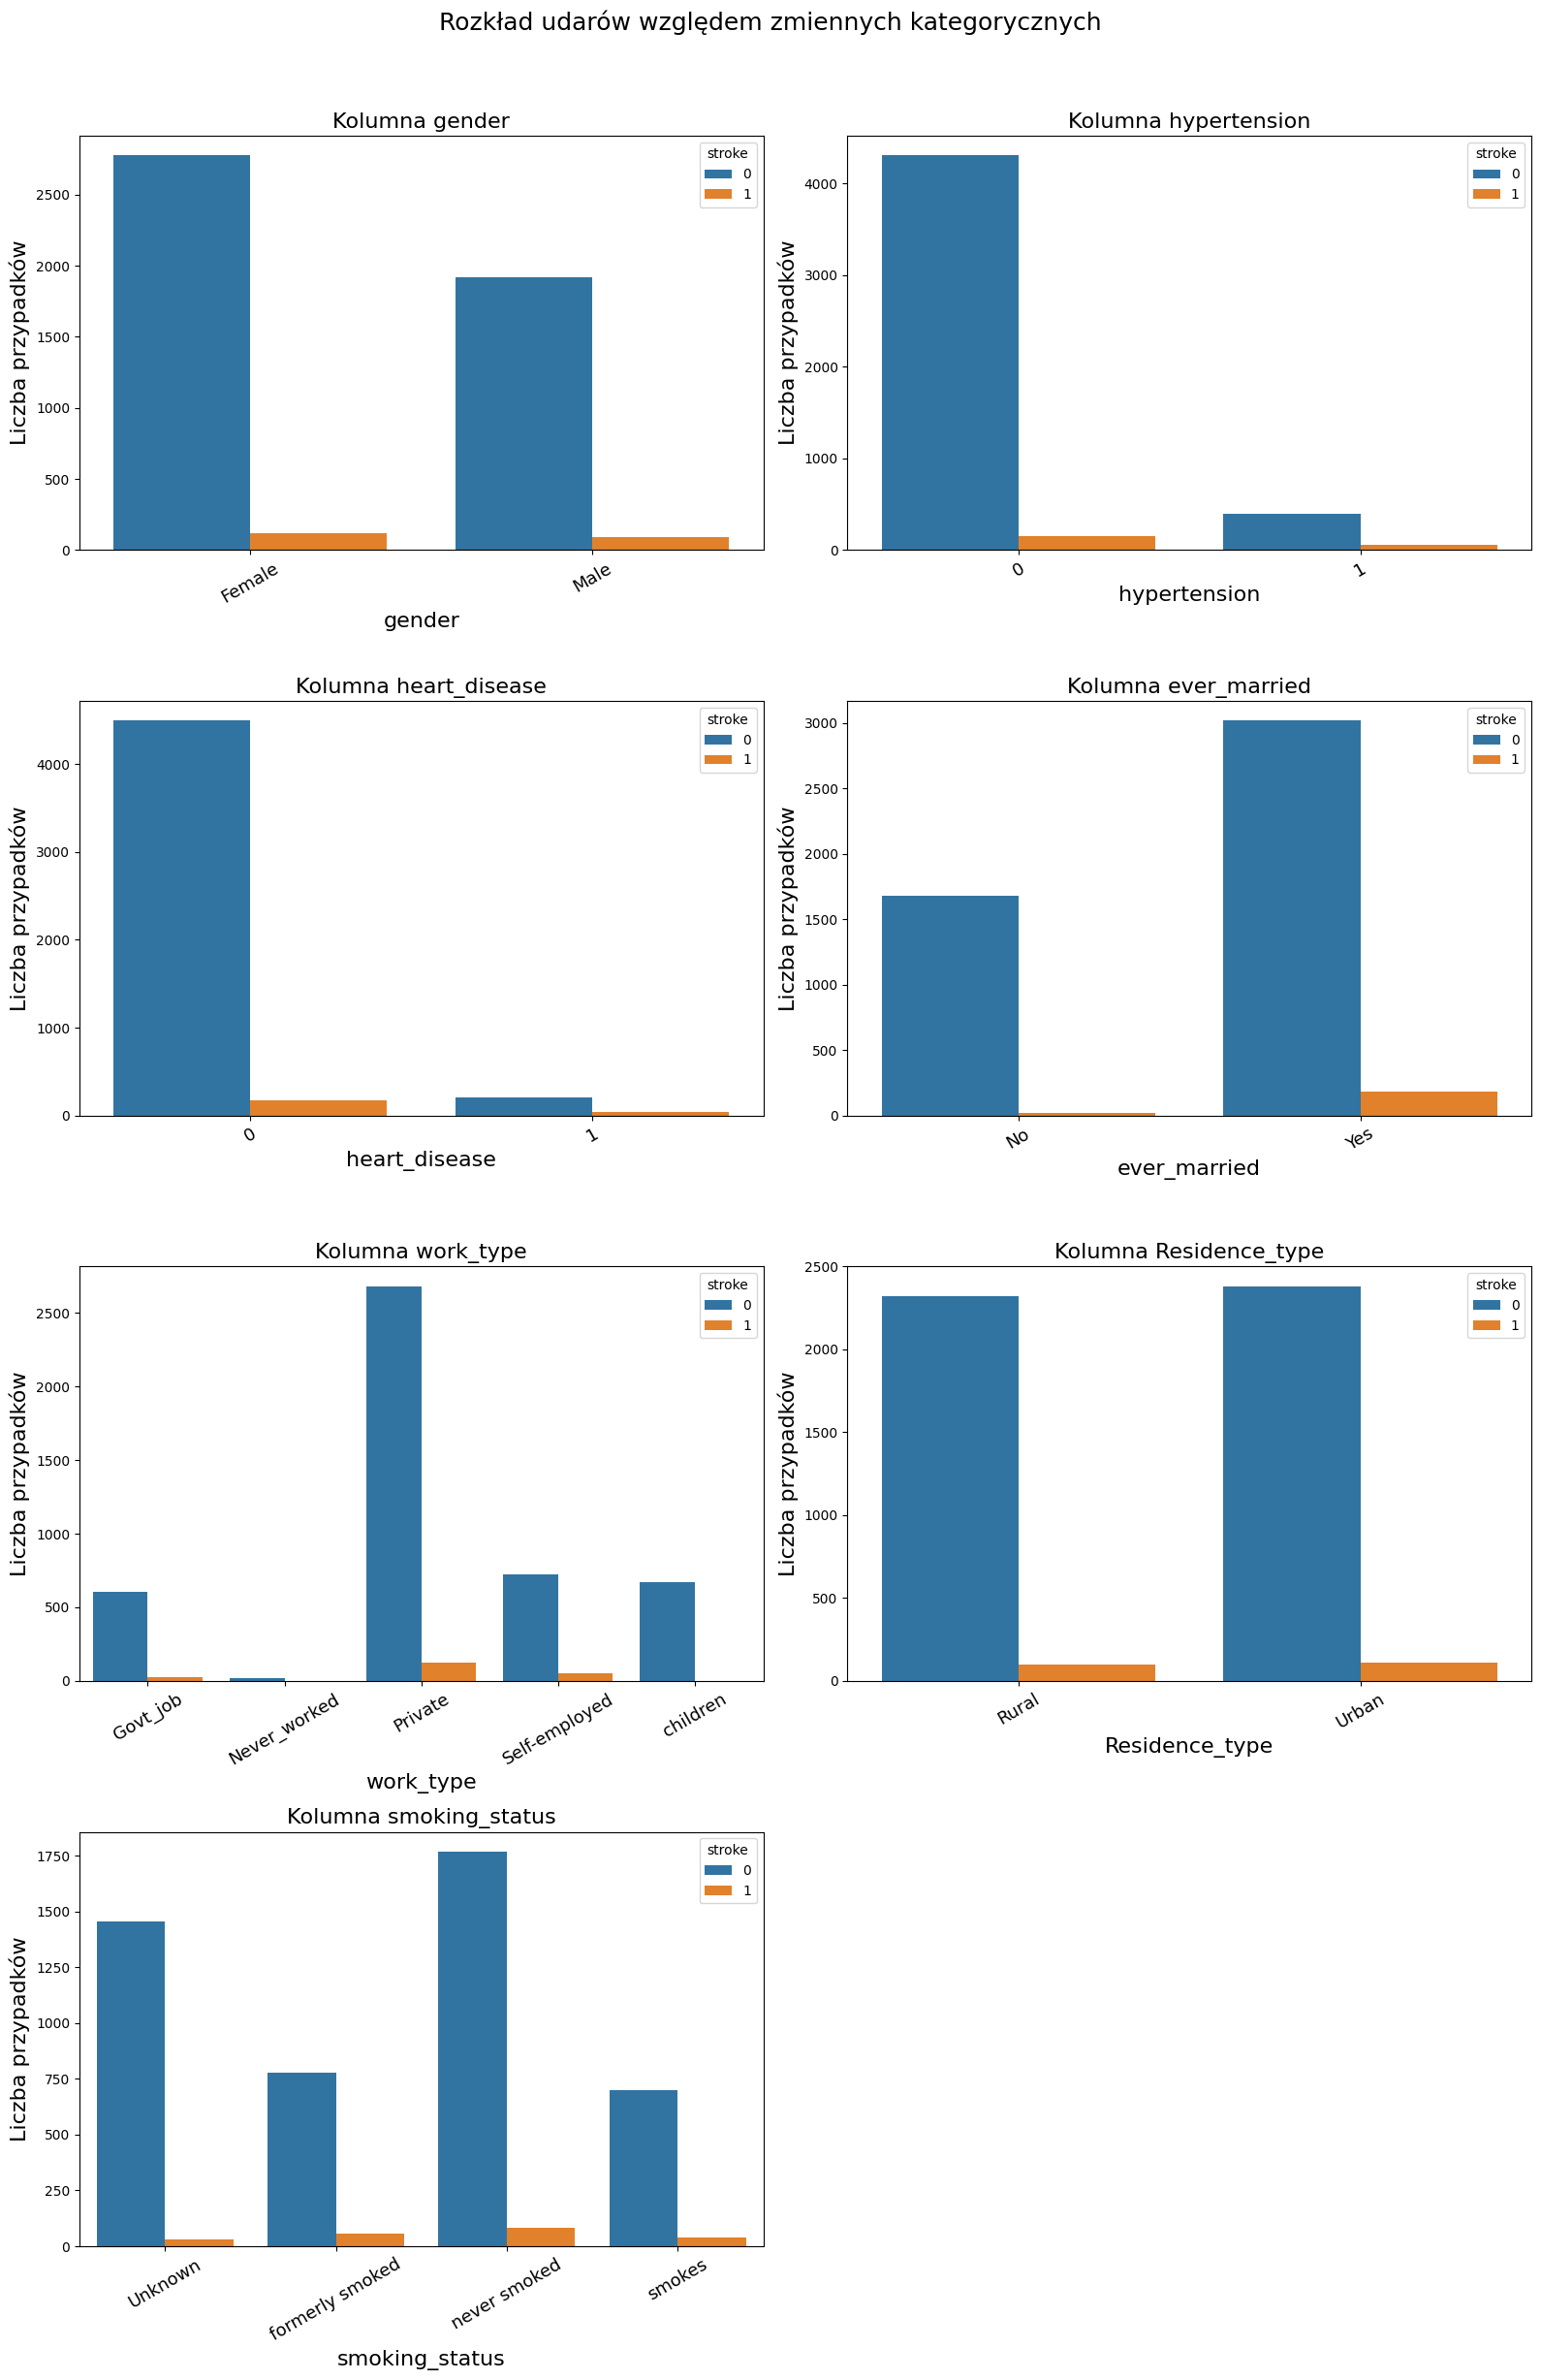

In [17]:
#Countplot — ile osób ma udar w każdej kategorii

fig, axes = plt.subplots(4, 2, figsize=(16, 25))
axes = axes.flatten()

for ax, col in zip(axes, columns):
    sns.countplot(data=df, x=col, hue='stroke', ax=ax)
    ax.set_title(f"Kolumna {col}", fontsize=16)
    ax.set_ylabel("Liczba przypadków", fontsize=16)
    ax.set_xlabel(f"{col}", fontsize=16)
    ax.tick_params(axis='x', rotation=30, labelsize=13)

# usuń pusty subplot
fig.delaxes(axes[-1])

fig.suptitle("Rozkład udarów względem zmiennych kategorycznych", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("Szablon_praca_inzynierska_GIN_IAD 1/img/stroke_by_col.png", dpi=300)
plt.show()

# Modele

In [18]:
df['stroke'].value_counts(normalize=True)

stroke
0    0.957416
1    0.042584
Name: proportion, dtype: float64

In [19]:
num_cols = ['age', 'avg_glucose_level', 'bmi']
cat_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

X_all = df[num_cols + cat_cols]
y = df['stroke']

X_all_trainval, X_all_test, y_trainval, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42, stratify=y
)
X_all_train, X_all_val, y_train, y_val = train_test_split(
    X_all_trainval, y_trainval, test_size=0.2, random_state=42, stratify=y_trainval
)

preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)

In [20]:
#BASELINE: Logistic Regression

X_num_train = X_all_train[num_cols]
X_num_val   = X_all_val[num_cols]
X_num_test  = X_all_test[num_cols]

model = Pipeline([
    ('scaler', MinMaxScaler()),
    ('logreg', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

#Trening
model.fit(X_num_train, y_train)

#Ewaluacja
y_pred = model.predict(X_num_test)
y_prob = model.predict_proba(X_num_test)[:, 1]

print("[LR] Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

print("\n[LR] Classification report:")
print(classification_report(y_test, y_pred, digits=4))

print("[LR] AUC:", roc_auc_score(y_test, y_prob))

[LR] Confusion matrix:
[[690 250]
 [ 11  31]]

[LR] Classification report:
              precision    recall  f1-score   support

           0     0.9843    0.7340    0.8410       940
           1     0.1103    0.7381    0.1920        42

    accuracy                         0.7342       982
   macro avg     0.5473    0.7361    0.5165       982
weighted avg     0.9469    0.7342    0.8132       982

[LR] AUC: 0.8111955420466059


In [21]:
#Model 2: Random Forest
rf = Pipeline([
    ('prep', preprocess),
    ('rf', RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    ))
])

rf.fit(X_all_train, y_train)

y_pred_rf = rf.predict(X_all_test)
y_prob_rf = rf.predict_proba(X_all_test)[:, 1]

print("\n[RF] Confusion matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\n[RF] Classification report:")
print(classification_report(y_test, y_pred_rf, digits=4))

print("[RF] AUC:", roc_auc_score(y_test, y_prob_rf))


[RF] Confusion matrix:
[[940   0]
 [ 42   0]]

[RF] Classification report:
              precision    recall  f1-score   support

           0     0.9572    1.0000    0.9781       940
           1     0.0000    0.0000    0.0000        42

    accuracy                         0.9572       982
   macro avg     0.4786    0.5000    0.4891       982
weighted avg     0.9163    0.9572    0.9363       982

[RF] AUC: 0.7742527862208713


C:\Users\wesol\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\wesol\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\wesol\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [22]:
#Model 3: XGBoost

#stosunek klasy 0 do klasy 1
ratio = (y_train == 0).sum() / (y_train == 1).sum()

xgb_pipe = Pipeline([
    ('prep', preprocess),
    ('xgb', XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='binary:logistic',
        eval_metric='logloss',
        scale_pos_weight=ratio,
        random_state=42,
        n_jobs=-1
    ))
])

xgb_pipe.fit(X_all_train, y_train)
y_prob_xgb = xgb_pipe.predict_proba(X_all_test)[:, 1]

y_pred_xgb = (y_prob_xgb >= 0.5).astype(int)  #domyślny próg

print("\n[XGBoost] Confusion matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print("\n[XGBoost] Classification report:")
print(classification_report(y_test, y_pred_xgb, digits=4))
print("[XGBoost] AUC:", roc_auc_score(y_test, y_prob_xgb))


[XGBoost] Confusion matrix:
[[839 101]
 [ 22  20]]

[XGBoost] Classification report:
              precision    recall  f1-score   support

           0     0.9744    0.8926    0.9317       940
           1     0.1653    0.4762    0.2454        42

    accuracy                         0.8747       982
   macro avg     0.5699    0.6844    0.5886       982
weighted avg     0.9398    0.8747    0.9024       982

[XGBoost] AUC: 0.8011398176291793


In [23]:
#Threshold tuning na val
thresholds = np.arange(0.05, 0.60, 0.05)

#prawd na VAL
y_prob_val = xgb_pipe.predict_proba(X_all_val)[:, 1]

print("\nTHRESHOLD TUNING:")
print("threshold | recall | precision | f1")

best_t, best_f1 = 0.5, -1

for t in thresholds:
    preds = (y_prob_val >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, preds).ravel()

    recall = tp / (tp + fn) if (tp + fn) else 0
    precision = tp / (tp + fp) if (tp + fp) else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0

    if f1 > best_f1:
        best_f1, best_t = f1, t

    print(f"{t:8.2f} | {recall:8.3f} | {precision:8.3f} | {f1:6.3f}")

print(f"\nBest threshold: {best_t:.2f} (F1={best_f1:.3f})")


THRESHOLD TUNING:
threshold | recall | precision | f1
    0.05 |    0.909 |    0.086 |  0.158
    0.10 |    0.848 |    0.100 |  0.178
    0.15 |    0.788 |    0.111 |  0.194
    0.20 |    0.788 |    0.124 |  0.215
    0.25 |    0.667 |    0.124 |  0.210
    0.30 |    0.576 |    0.128 |  0.209
    0.35 |    0.485 |    0.121 |  0.194
    0.40 |    0.424 |    0.117 |  0.183
    0.45 |    0.394 |    0.123 |  0.187
    0.50 |    0.394 |    0.140 |  0.206
    0.55 |    0.394 |    0.149 |  0.217

Best threshold: 0.55 (F1=0.217)


In [24]:
#Final evaluation z dobranym progiem

y_prob_tuned = xgb_pipe.predict_proba(X_all_test)[:, 1]
y_pred_tuned = (y_prob_tuned >= best_t).astype(int)

print(f"[XGBoost Tuning] Confusion matrix (threshold={best_t:.2f}):")
print(confusion_matrix(y_test, y_pred_tuned))

print("\n[XGBoost Tuning] Classification report (TEST):")
print(classification_report(y_test, y_pred_tuned, digits=4))

print("[XGBoost Tuning] AUC:", roc_auc_score(y_test, y_prob_tuned))

[XGBoost Tuning] Confusion matrix (threshold=0.55):
[[855  85]
 [ 24  18]]

[XGBoost Tuning] Classification report (TEST):
              precision    recall  f1-score   support

           0     0.9727    0.9096    0.9401       940
           1     0.1748    0.4286    0.2483        42

    accuracy                         0.8890       982
   macro avg     0.5737    0.6691    0.5942       982
weighted avg     0.9386    0.8890    0.9105       982

[XGBoost Tuning] AUC: 0.8011398176291793


In [25]:
#SMOTENC (na surowych kategoriach)

#skalowanie numerycznych
pre_smote = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', 'passthrough', cat_cols),
    ],
    remainder='drop'
)

cat_pos = list(range(len(num_cols), len(num_cols) + len(cat_cols)))

#OneHot tylko na kategorycznych
post_smote = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_pos)
    ],
    remainder='passthrough'
)

pipe_smote = ImbPipeline([
    ('pre_smote', pre_smote),
    ('smote', SMOTENC(categorical_features=cat_pos, random_state=42)),
    ('post_smote', post_smote),
    ('clf', XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

pipe_smote.fit(X_all_train, y_train)

y_prob_smote = pipe_smote.predict_proba(X_all_test)[:, 1]
y_pred_smote = (y_prob_smote >= 0.5).astype(int)

print("\n[SMOTENC + XGB] Confusion matrix:")
print(confusion_matrix(y_test, y_pred_smote))

print("\n[SMOTENC + XGB] Classification report:")
print(classification_report(y_test, y_pred_smote, digits=4))

print("[SMOTENC + XGB] AUC:", roc_auc_score(y_test, y_prob_smote))


[SMOTENC + XGB] Confusion matrix:
[[832 108]
 [ 27  15]]

[SMOTENC + XGB] Classification report:
              precision    recall  f1-score   support

           0     0.9686    0.8851    0.9250       940
           1     0.1220    0.3571    0.1818        42

    accuracy                         0.8625       982
   macro avg     0.5453    0.6211    0.5534       982
weighted avg     0.9324    0.8625    0.8932       982

[SMOTENC + XGB] AUC: 0.7748986828774063


In [26]:
#Oversampling + XGBoost

pipe_over = ImbPipeline([
    ('prep', preprocess),
    ('over', RandomOverSampler(random_state=42)),
    ('clf', XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

pipe_over.fit(X_all_train, y_train)

y_prob_over = pipe_over.predict_proba(X_all_test)[:, 1]
y_pred_over = (y_prob_over >= 0.5).astype(int)

print("\n[OverSampling + XGB] Confusion matrix:")
print(confusion_matrix(y_test, y_pred_over))

print("\n[OverSampling + XGB] Classification report:")
print(classification_report(y_test, y_pred_over, digits=4))

print("[OverSampling + XGB] AUC:", roc_auc_score(y_test, y_prob_over))


[OverSampling + XGB] Confusion matrix:
[[842  98]
 [ 23  19]]

[OverSampling + XGB] Classification report:
              precision    recall  f1-score   support

           0     0.9734    0.8957    0.9330       940
           1     0.1624    0.4524    0.2390        42

    accuracy                         0.8768       982
   macro avg     0.5679    0.6741    0.5860       982
weighted avg     0.9387    0.8768    0.9033       982

[OverSampling + XGB] AUC: 0.7863475177304964


In [27]:
#Undersampling + XGBoost
pipe_under = ImbPipeline([
    ('prep', preprocess),
    ('under', RandomUnderSampler(random_state=42)),
    ('clf', XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])

pipe_under.fit(X_all_train, y_train)

y_prob_under = pipe_under.predict_proba(X_all_test)[:, 1]
y_pred_under = (y_prob_under >= 0.5).astype(int)

print("\n[UnderSampling + XGB] Confusion matrix:")
print(confusion_matrix(y_test, y_pred_under))

print("\n[UnderSampling + XGB] Classification report:")
print(classification_report(y_test, y_pred_under, digits=4))

print("[UnderSampling + XGB] AUC:", roc_auc_score(y_test, y_prob_under))


[UnderSampling + XGB] Confusion matrix:
[[639 301]
 [  9  33]]

[UnderSampling + XGB] Classification report:
              precision    recall  f1-score   support

           0     0.9861    0.6798    0.8048       940
           1     0.0988    0.7857    0.1755        42

    accuracy                         0.6843       982
   macro avg     0.5425    0.7328    0.4902       982
weighted avg     0.9482    0.6843    0.7779       982

[UnderSampling + XGB] AUC: 0.8000253292806484


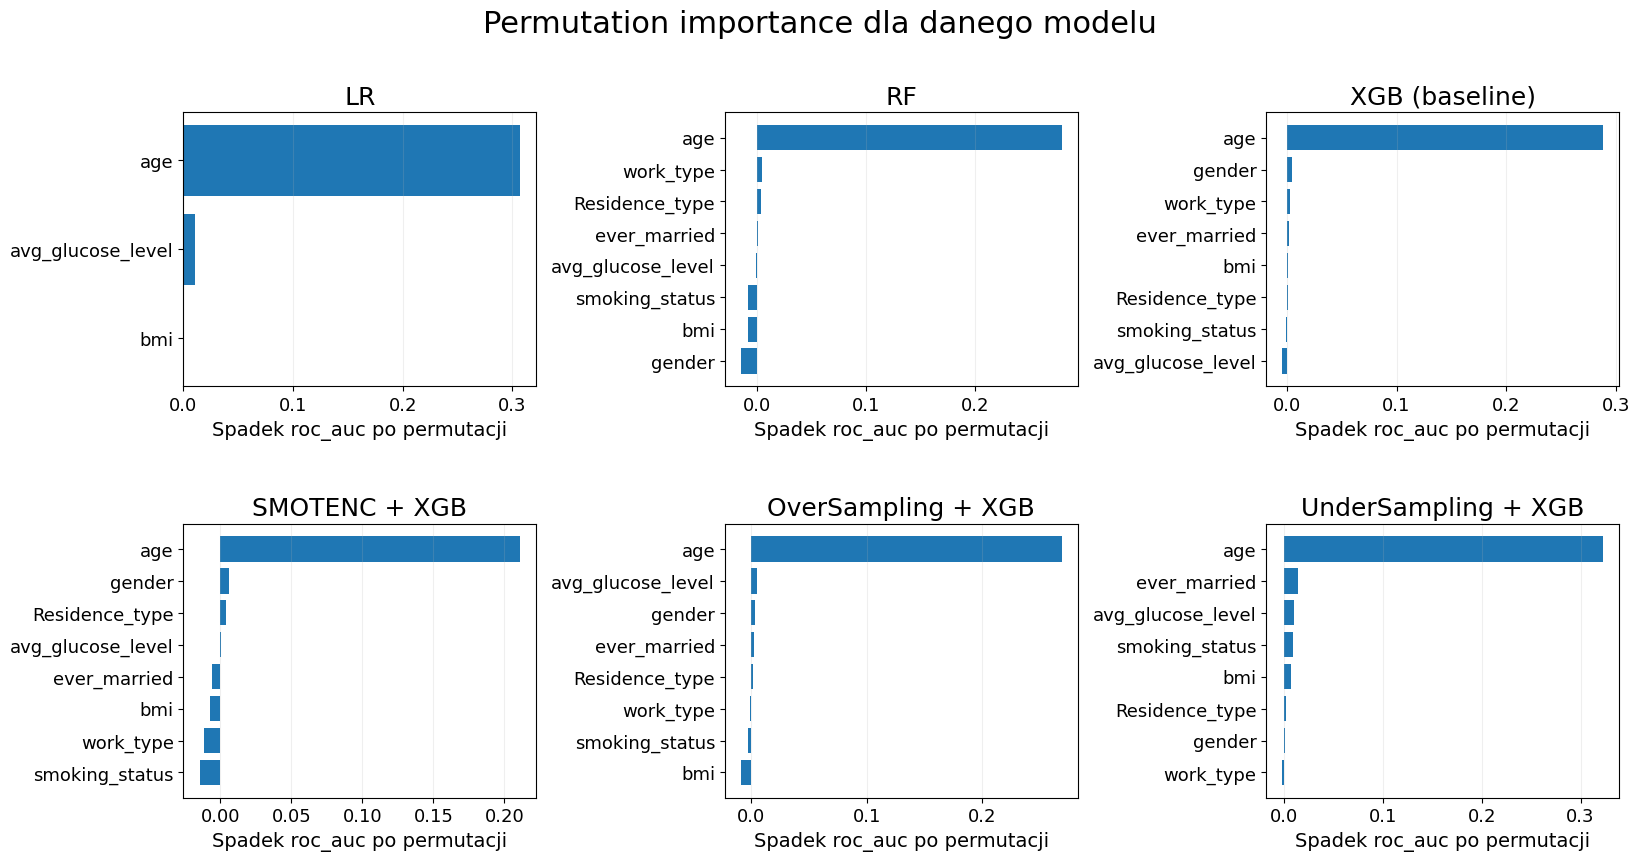

In [28]:
#permutation importance
TOP_K = 10
N_REPEATS = 10
SCORING = "roc_auc"  #sprawdzam zdolnosc modelu do rozroznienia klas

def perm_imp_df(estimator, X, y, scoring="roc_auc", n_repeats=10, random_state=42):
    r = permutation_importance(
        estimator, X, y,
        n_repeats=n_repeats,
        random_state=random_state,
        scoring=scoring,
        n_jobs=-1
    )
    return (pd.DataFrame({
        "feature": X.columns,
        "mean": r.importances_mean,
        "std": r.importances_std
    }).sort_values("mean", ascending=False))

#lista modeli do porownania
models_to_compare = [
    ("LR", model, X_num_val),
    ("RF", rf, X_all_val),
    ("XGB (baseline)", xgb_pipe, X_all_val), #bez wersji tuned bo będzie takie samo jak baseline
    ("SMOTENC + XGB", pipe_smote, X_all_val),
    ("OverSampling + XGB", pipe_over, X_all_val),
    ("UnderSampling + XGB", pipe_under, X_all_val),
]

#liczenie importance
imps = []
for name, est, Xmat in models_to_compare:
    imp = perm_imp_df(est, Xmat, y_val, scoring=SCORING, n_repeats=N_REPEATS)
    imps.append((name, imp))

#rysowanie w jednej figurze
n = len(imps)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5.5, rows * 4.2))
fig.suptitle("Permutation importance dla danego modelu", fontsize=22, y=1.02)
axes = np.array(axes).reshape(rows, cols)

for i, (name, imp) in enumerate(imps):
    r, c = divmod(i, cols)
    ax = axes[r, c]

    top = imp.head(TOP_K).iloc[::-1]
    ax.barh(top["feature"], top["mean"])
    ax.set_title(name, fontsize=18)
    ax.set_xlabel(f"Spadek {SCORING} po permutacji", fontsize=14)
    ax.tick_params(axis="x", labelsize=13)
    ax.tick_params(axis="y", labelsize=13)
    ax.grid(True, axis="x", alpha=0.2)

#usun puste osie
for j in range(n, rows * cols):
    r, c = divmod(j, cols)
    fig.delaxes(axes[r, c])

plt.tight_layout()
fig.subplots_adjust(hspace=0.5)
plt.savefig("Szablon_praca_inzynierska_GIN_IAD 1/img/permutation_importance.png", dpi=300)
plt.show()

In [29]:
#porownanie modeli w tabeli
def model_metrics(name, y_true, y_pred, y_prob):
    from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
    
    return {
        "Model": name,
        "Recall (stroke)": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Precision (stroke)": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "F1 (stroke)": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob),
    }

results = []

#Logistic Regression
results.append(
    model_metrics(
        "Logistic Regression",
        y_test,
        y_pred,       
        y_prob         
    )
)

#Random Forest
results.append(
    model_metrics(
        "Random Forest",
        y_test,
        y_pred_rf,
        y_prob_rf
    )
)

#XGBoost
results.append(
    model_metrics(
        "XGBoost",
        y_test,
        y_pred_xgb,
        y_prob_xgb
    )
)

# XGBoost threshold
results.append(
    model_metrics(
        "XGBoost (tuned threshold)",
        y_test,
        y_pred_tuned,
        y_prob_tuned
    )
)

#SMOTENC + XGB
results.append(
    model_metrics(
        "SMOTENC + XGBoost",
        y_test,
        y_pred_smote,
        y_prob_smote
    )
)

#OverSampling + XGB
results.append(
    model_metrics(
        "OverSampling + XGBoost",
        y_test,
        y_pred_over,
        y_prob_over
    )
)

#UnderSampling + XGB
results.append(
    model_metrics(
        "UnderSampling + XGBoost",
        y_test,
        y_pred_under,
        y_prob_under
    )
)

results_df = pd.DataFrame(results)
results_df = results_df[[
    "Model", "Recall (stroke)", "Precision (stroke)", "F1 (stroke)", "ROC-AUC", "PR-AUC"
]]

results_df = results_df.sort_values("Recall (stroke)", ascending=False)
results_df.round(3)

,Model,Recall (stroke),Precision (stroke),F1 (stroke),ROC-AUC,PR-AUC
6,UnderSampling + XGBoost,0.786,0.099,0.176,0.800,0.136
0,Logistic Regression,0.738,0.110,0.192,0.811,0.218
2,XGBoost,0.476,0.165,0.245,0.801,0.137
5,OverSampling + XGBoost,0.452,0.162,0.239,0.786,0.143
3,XGBoost (tuned threshold),0.429,0.175,0.248,0.801,0.137
4,SMOTENC + XGBoost,0.357,0.122,0.182,0.775,0.138
1,Random Forest,0.000,0.000,0.000,0.774,0.131


In [30]:
#PCA/klastry jako EDA: “czy klasy się separują”, “czy są grupy pacjentów”; opisać, jak mocno klasy się mieszają

#tylko cechy numeryczne
X_num_train = X_all_train[num_cols]
X_num_val   = X_all_val[num_cols]
X_num_test  = X_all_test[num_cols]

#standaryzacja + PCA
scaler = StandardScaler()
Xtr_s = scaler.fit_transform(X_num_train)
Xva_s = scaler.transform(X_num_val)
Xte_s = scaler.transform(X_num_test)

pca = PCA(n_components=2)
Ztr = pca.fit_transform(Xtr_s)
Zva = pca.transform(Xva_s)
Zte = pca.transform(Xte_s)

print("Udział wyjaśnionej wariancji:", pca.explained_variance_ratio_)
print("Łączny udział wyjaśnionej wariancji:", pca.explained_variance_ratio_.sum())

Udział wyjaśnionej wariancji: [0.50151423 0.27954684]
Łączny udział wyjaśnionej wariancji: 0.781061069572915


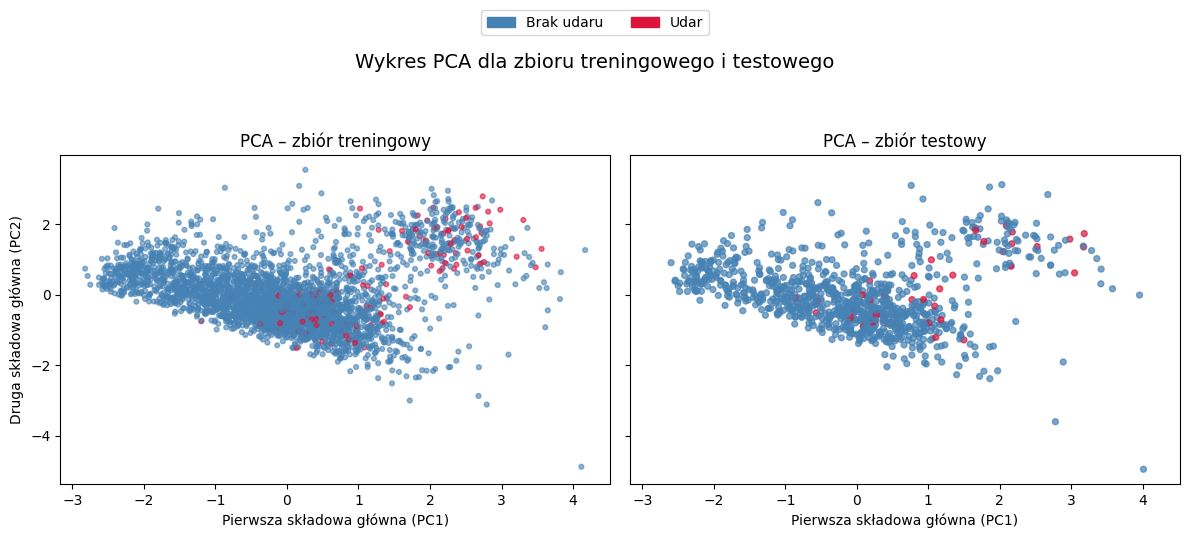

In [31]:
#wykres PCA
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
fig.suptitle("Wykres PCA dla zbioru treningowego i testowego", fontsize=14)
colors = {0: "steelblue", 1: "crimson"}

#TRAIN
axes[0].scatter(
    Ztr[:, 0], Ztr[:, 1],
    c=[colors[v] for v in y_train],
    s=12, alpha=0.6
)
axes[0].set_title("PCA – zbiór treningowy")
axes[0].set_xlabel("Pierwsza składowa główna (PC1)")
axes[0].set_ylabel("Druga składowa główna (PC2)")

#TEST
axes[1].scatter(
    Zte[:, 0], Zte[:, 1],
    c=[colors[v] for v in y_test],
    s=18, alpha=0.7
)
axes[1].set_title("PCA – zbiór testowy")
axes[1].set_xlabel("Pierwsza składowa główna (PC1)")

#legenda
legend_elements = [
    mpatches.Patch(color="steelblue", label="Brak udaru"),
    mpatches.Patch(color="crimson", label="Udar")
]
fig.legend(handles=legend_elements, loc="upper center", ncol=2,
           bbox_to_anchor=(0.5, 1.08))
plt.tight_layout(rect=[0, 0, 1, 0.92])

plt.savefig("Szablon_praca_inzynierska_GIN_IAD 1/img/pca.png", dpi=300)
plt.show()

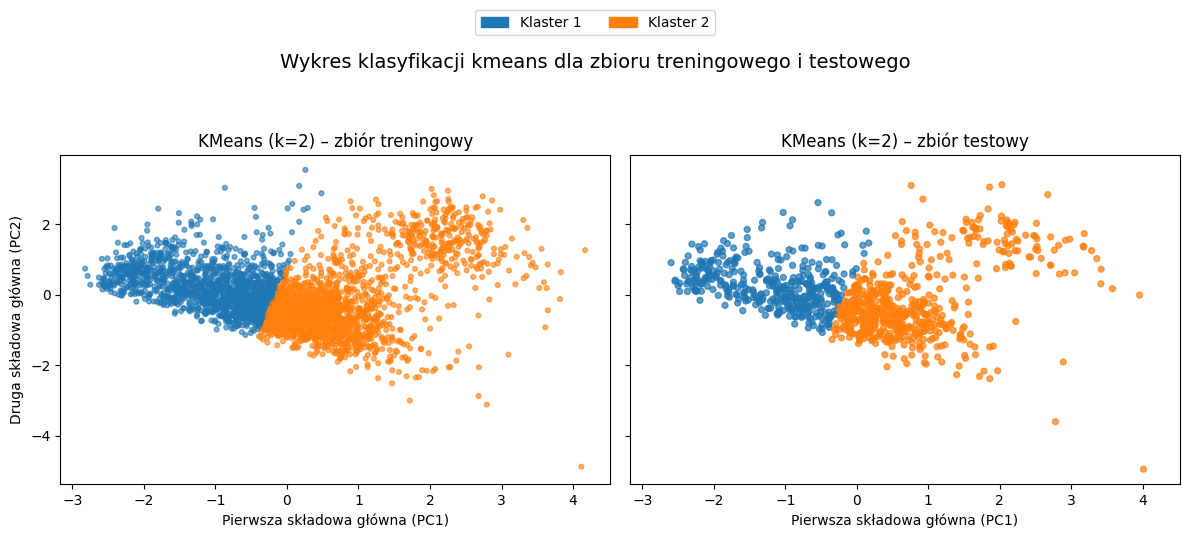

In [32]:
#KMeans na PCA
k = 2
kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)

clusters_tr = kmeans.fit_predict(Ztr)
clusters_te = kmeans.predict(Zte)

#kolory klastrow
cluster_colors = ["tab:blue", "tab:orange", "tab:green"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
fig.suptitle("Wykres klasyfikacji kmeans dla zbioru treningowego i testowego", fontsize=14)
#TRAIN
axes[0].scatter(
    Ztr[:, 0],
    Ztr[:, 1],
    c=[cluster_colors[c] for c in clusters_tr],
    s=12,
    alpha=0.6
)
axes[0].set_title("KMeans (k=2) – zbiór treningowy")
axes[0].set_xlabel("Pierwsza składowa główna (PC1)")
axes[0].set_ylabel("Druga składowa główna (PC2)")

#TEST
axes[1].scatter(
    Zte[:, 0],
    Zte[:, 1],
    c=[cluster_colors[c] for c in clusters_te],
    s=18,
    alpha=0.7
)
axes[1].set_title("KMeans (k=2) – zbiór testowy")
axes[1].set_xlabel("Pierwsza składowa główna (PC1)")

#legenda
legend_elements = [
    mpatches.Patch(color=cluster_colors[i], label=f"Klaster {i+1}")
    for i in range(k)
]
fig.legend(handles=legend_elements, loc="upper center", ncol=2,
           bbox_to_anchor=(0.5, 1.08))
plt.tight_layout(rect=[0, 0, 1, 0.92])

plt.savefig("Szablon_praca_inzynierska_GIN_IAD 1/img/kmeans.png", dpi=300)
plt.show()

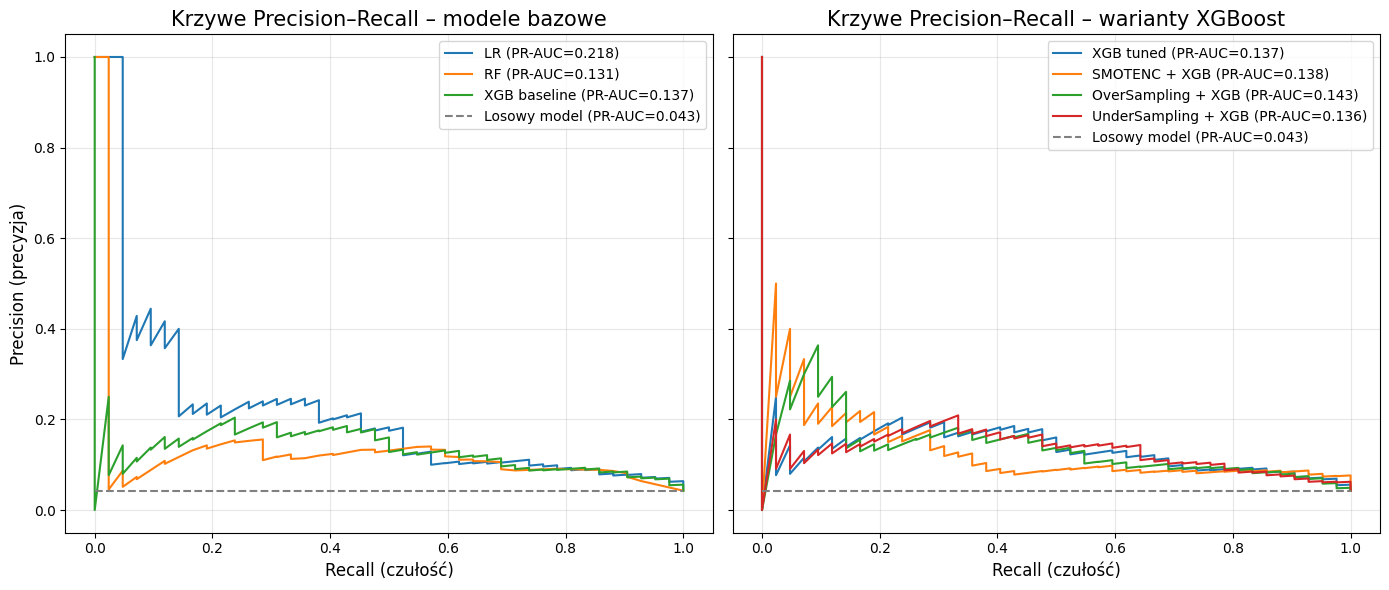

In [33]:
#pr-auc wykres : pokazanie kompromisu miedzy czuloscia a precyzja
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

#WYKRES 1 – MODELE BAZOWE
models_base = [
    ("LR", y_prob),
    ("RF", y_prob_rf),
    ("XGB baseline", y_prob_xgb),
]

for name, y_prob in models_base:
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)
    axes[0].plot(recall, precision, label=f"{name} (PR-AUC={pr_auc:.3f})")

#losowy model
baseline = y_test.mean()
axes[0].hlines(
    baseline, xmin=0, xmax=1,
    colors="gray", linestyles="dashed",
    label=f"Losowy model (PR-AUC={baseline:.3f})"
)

axes[0].set_title("Krzywe Precision–Recall – modele bazowe", fontsize=15)
axes[0].set_xlabel("Recall (czułość)", fontsize= 12)
axes[0].set_ylabel("Precision (precyzja)", fontsize= 12)
axes[0].legend()
axes[0].grid(alpha=0.3)

#WYKRES 2 – XGBOOST (WARIANTY)
models_adv = [
    ("XGB tuned", y_prob_tuned),
    ("SMOTENC + XGB", y_prob_smote),
    ("OverSampling + XGB", y_prob_over),
    ("UnderSampling + XGB", y_prob_under),
]

for name, y_prob in models_adv:
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)
    axes[1].plot(recall, precision, label=f"{name} (PR-AUC={pr_auc:.3f})")

axes[1].hlines(
    baseline, xmin=0, xmax=1,
    colors="gray", linestyles="dashed",
    label=f"Losowy model (PR-AUC={baseline:.3f})"
)

axes[1].set_title("Krzywe Precision–Recall – warianty XGBoost", fontsize=15)
axes[1].set_xlabel("Recall (czułość)", fontsize= 12)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("Szablon_praca_inzynierska_GIN_IAD 1/img/pr_auc.png", dpi=300)
plt.show()